<a href="https://colab.research.google.com/github/jhj5445/portfolio/blob/main/sectorport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===

🏆 성과 비교 (분석 기간: 2000-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    11.86 % |   -39.02 % |       0.65
📈 SPY (S&P500) |     7.78 % |   -55.19 % |       0.48
-----------------------------------------------------------------
※ 누적 거래 수수료: 17.45% (정밀 차감 완료)



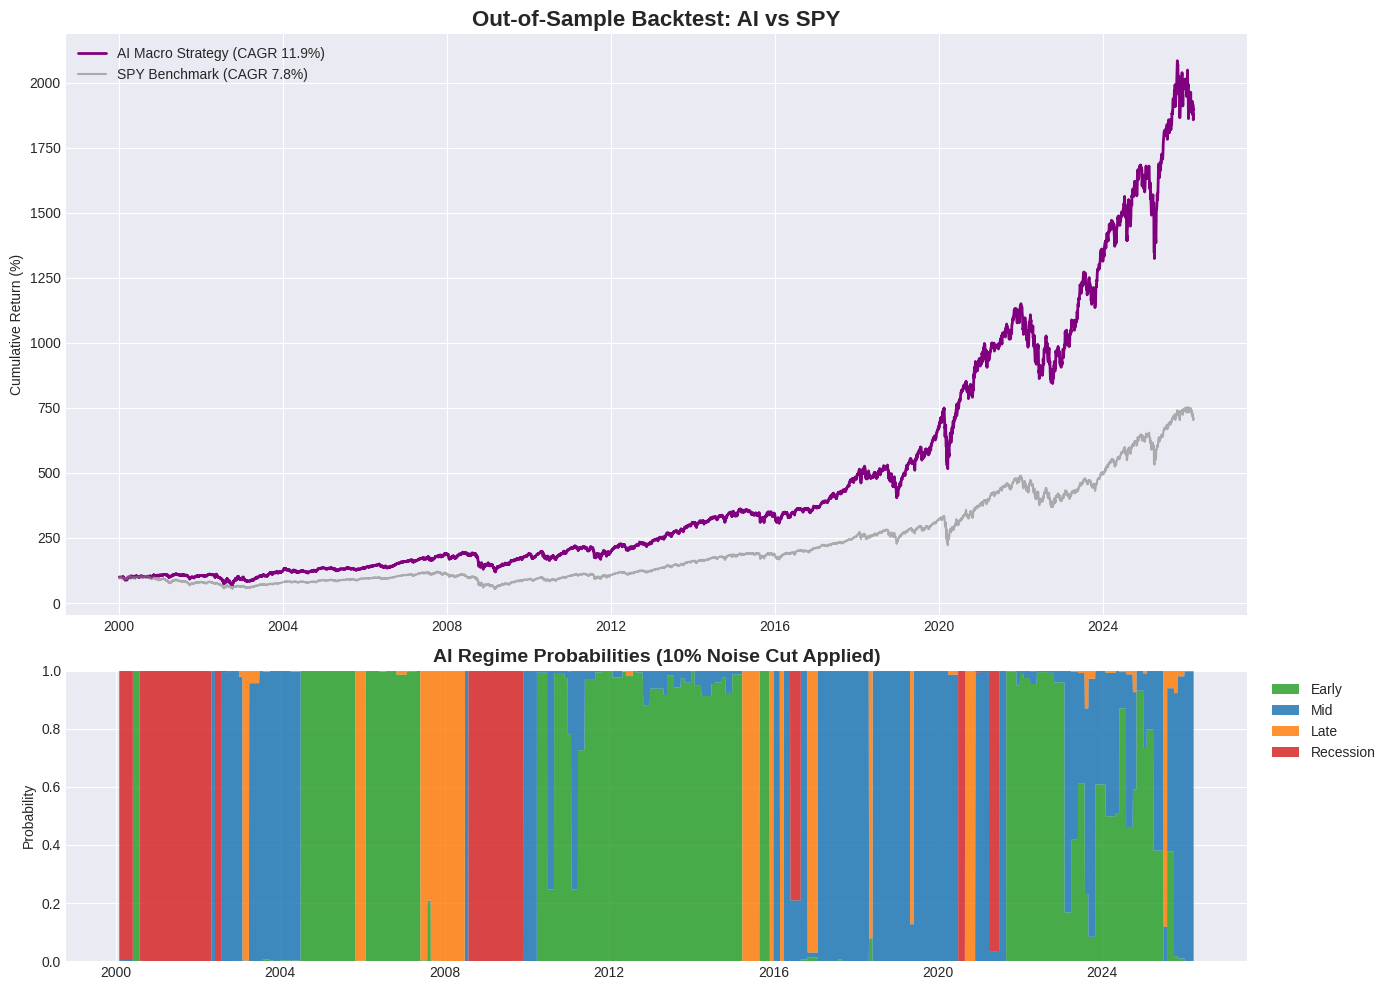

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직 (Late XLV 추가, Recession XLY 삭제 완료!)
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 비중 자연 표류 + 정밀 수수료)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (리밸런싱 안 하는 날은 NaN)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 💡[버그 수정] 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당!
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화 (2003년 동시 출발)
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2000-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
#rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
#rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
#rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
#print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
#ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===

🏆 성과 비교 (분석 기간: 2003-05-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    13.56 % |   -39.02 % |       0.74
📈 SPY (S&P500) |    11.01 % |   -55.19 % |       0.66
⚖️ RSP (동일가중) |    10.91 % |   -59.92 % |       0.62
-----------------------------------------------------------------
※ 누적 거래 수수료: 14.68% (정밀 차감 완료)



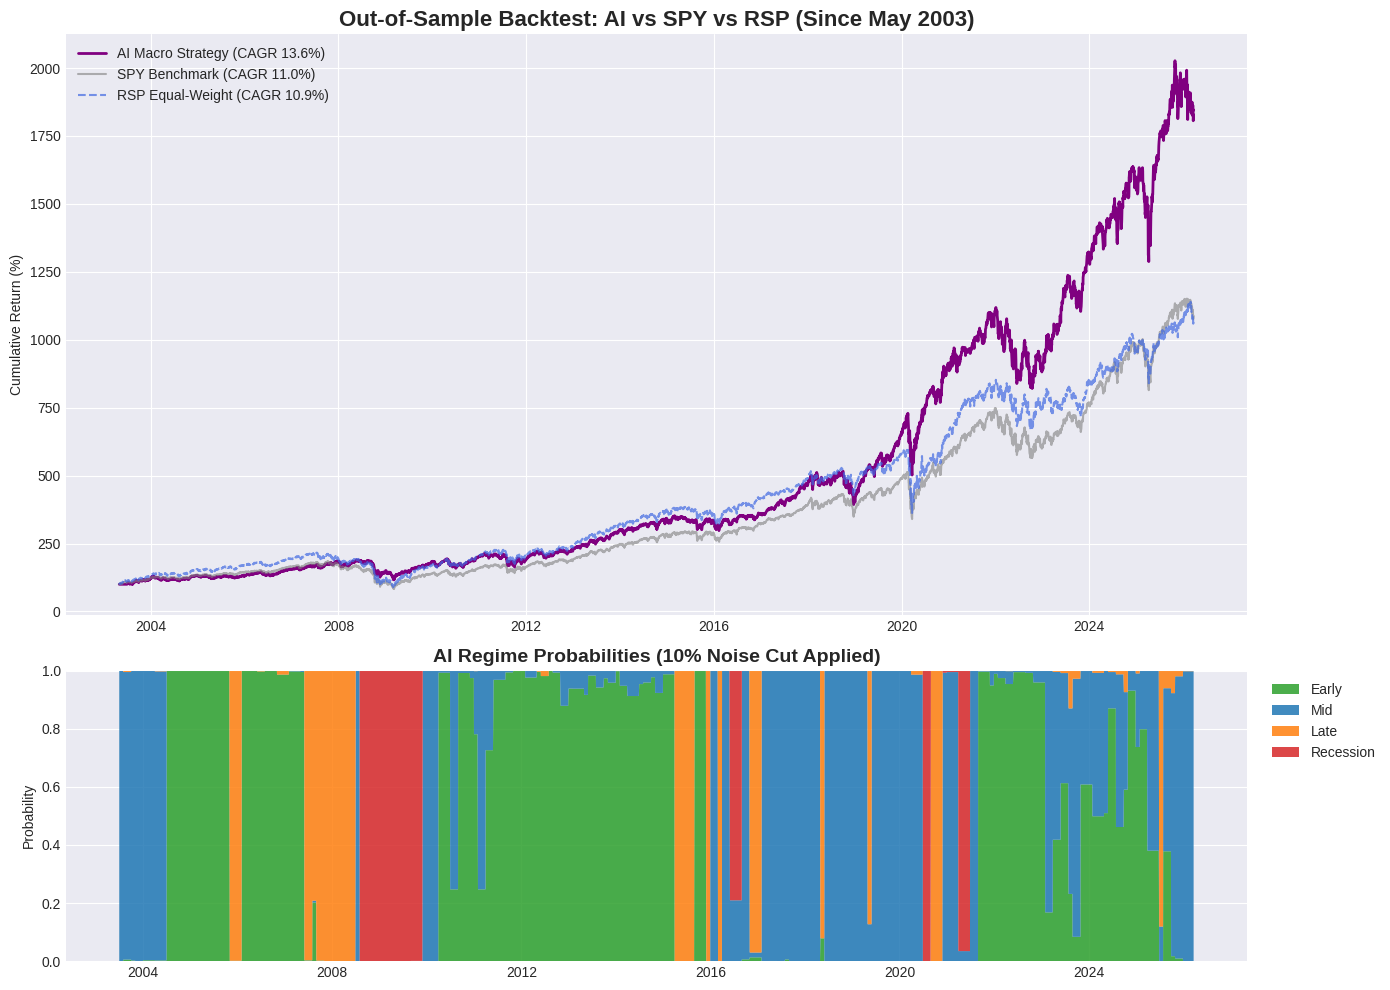

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','RSP']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직 (Late XLV 추가, Recession XLY 삭제 완료!)
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 비중 자연 표류 + 정밀 수수료)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (리밸런싱 안 하는 날은 NaN)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 💡[버그 수정] 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당!
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화 (2003년 동시 출발)
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2003-05-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY vs RSP (Since May 2003)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===

🏆 성과 비교 (분석 기간: 2021-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    14.31 % |   -26.60 % |       0.76
📈 SPY (S&P500) |    12.95 % |   -24.50 % |       0.80
⚖️ RSP (동일가중) |     9.88 % |   -21.38 % |       0.66
-----------------------------------------------------------------
※ 누적 거래 수수료: 3.78% (정밀 차감 완료)



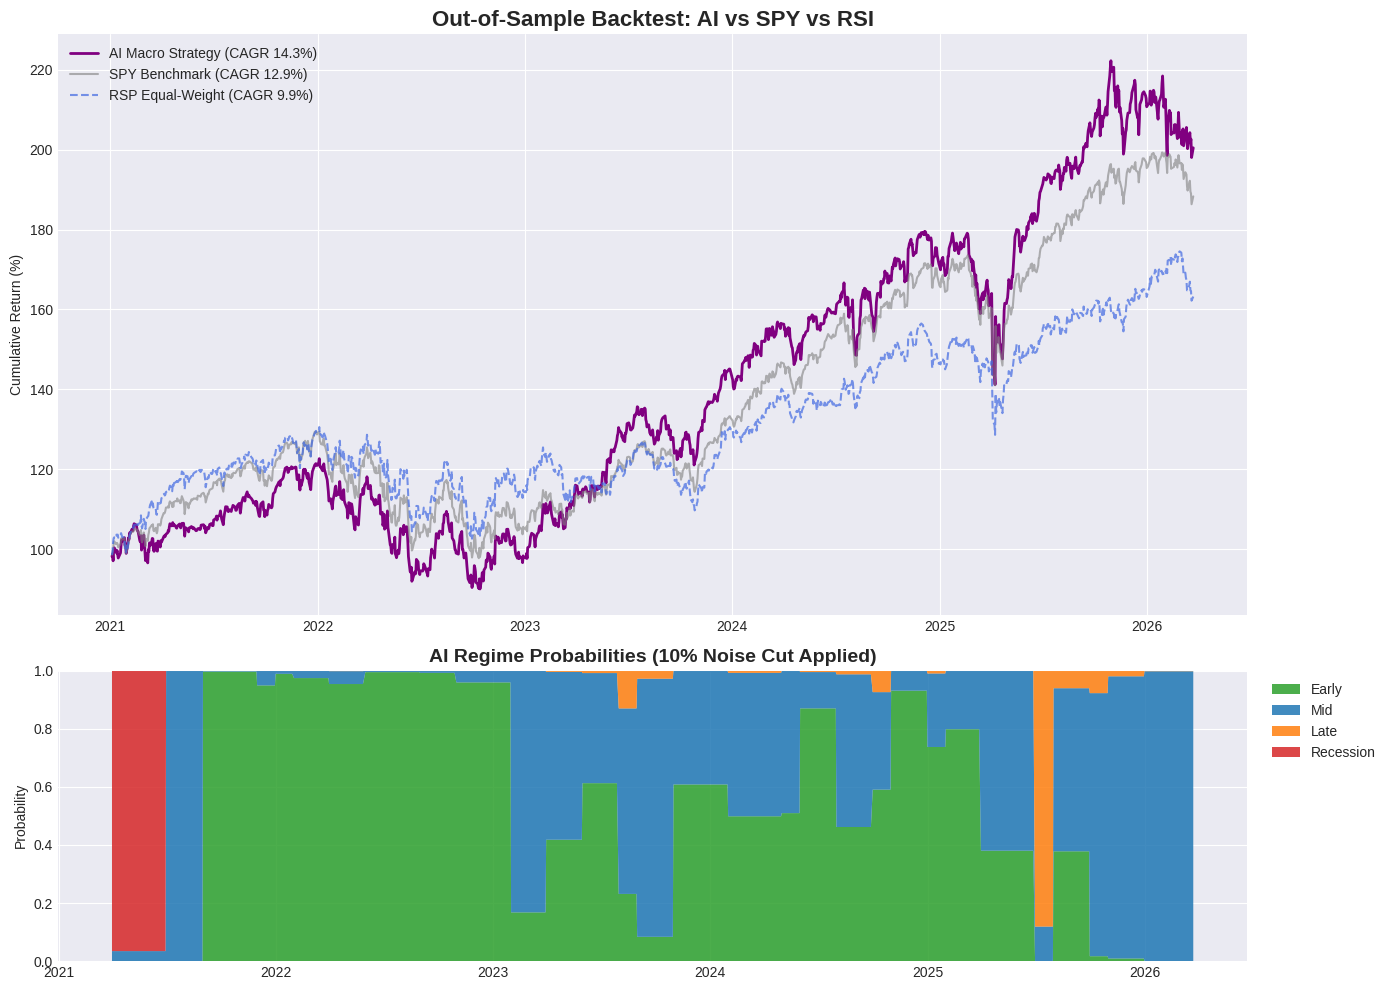

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','RSP']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2020-12-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직 (Late XLV 추가, Recession XLY 삭제 완료!)
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 비중 자연 표류 + 정밀 수수료)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (리밸런싱 안 하는 날은 NaN)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 💡[버그 수정] 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당!
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화 (2003년 동시 출발)
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2021-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY vs RSI', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# 5. 💾 실전 투자용 포트폴리오 비중 엑셀(CSV) 추출
# ==============================================================================
print("\n=== 💾 5단계: 월별 ETF 투자 비중 CSV 파일 저장 ===")

# 보기 편하도록 비중에 100을 곱해 퍼센트(%) 단위로 바꾸고, 소수점 둘째 자리까지 반올림
export_weights = (target_weights * 100).round(2)

# 인덱스(날짜) 포맷을 'YYYY-MM-DD'로 깔끔하게 정리
export_weights.index = export_weights.index.strftime('%Y-%m-%d')

# 파일명에 오늘 날짜를 넣어서 생성
today_str = pd.Timestamp.today().strftime('%Y%m%d')
file_name = f"Macro_AI_Portfolio_Weights_{today_str}.csv"

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
export_weights.to_csv(file_name, encoding='utf-8-sig')

print(f"✅ 저장 완료! 현재 파이썬 코드가 있는 폴더에 '{file_name}' 파일이 생성되었습니다.")

# 보너스: 콘솔 창에서도 가장 최근(이번 달) 비중을 바로 확인할 수 있게 출력
latest_date = export_weights.index[-1]
latest_weights = export_weights.iloc[-1]
active_positions = latest_weights[latest_weights > 0] # 비중이 0%인 건 빼고 출력

print(f"\n🔔 [가장 최근 리밸런싱 지시서: {latest_date} 기준]")
print("-" * 40)
for ticker, weight in active_positions.items():
    print(f"💰 {ticker:<4} : {weight:>6}%")
print("-" * 40)


=== 💾 5단계: 월별 ETF 투자 비중 CSV 파일 저장 ===


NameError: name 'target_weights' is not defined

In [2]:
# 1. 코랩 리눅스 서버에 나눔고딕 폰트 조용히 설치
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 파이썬 폰트 매니저에게 방금 깐 폰트 위치를 강제로 주입 (핵심!)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 3. 도화지(matplotlib) 기본 폰트를 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')

# 4. 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("✅ 코랩 한글 폰트 강제 패치 완료! 이제 3D 그래프를 다시 그려보세요.")

✅ 코랩 한글 폰트 강제 패치 완료! 이제 3D 그래프를 다시 그려보세요.



=== 📊 6단계: 3D GMM 클러스터링 시각화 생성 중 ===


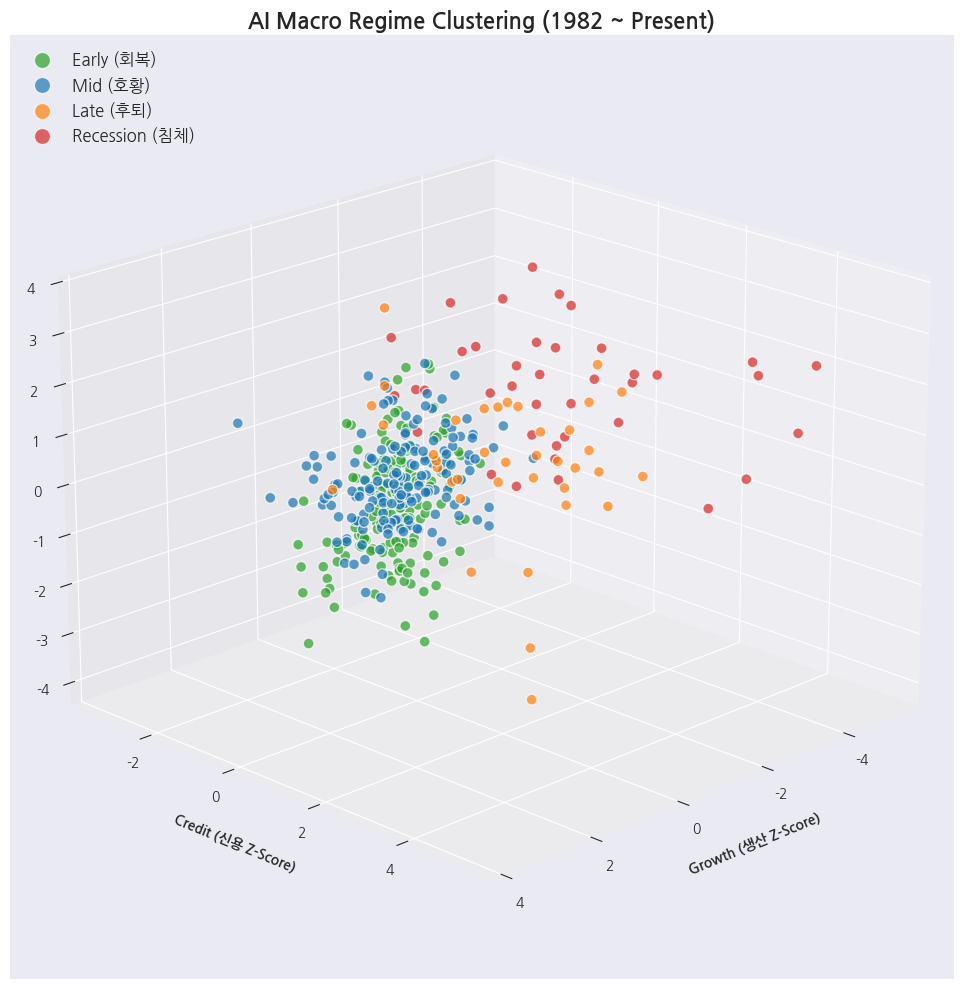

In [3]:
# ==============================================================================
# 6. 📊 프레젠테이션용 3D GMM 국면 시각화 (Scatter Plot)
# ==============================================================================

# ==========================================
print("\n=== 📊 6단계: 3D GMM 클러스터링 시각화 생성 중 ===")
from mpl_toolkits.mplot3d import Axes3D

# 전체 데이터를 기준으로 GMM 최종 학습 및 라벨링 (시각화용)
gmm_viz = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_labels = gmm_viz.fit_predict(df_z[features])
centroids_viz = gmm_viz.means_

# 국면 이름표 달기 (기존 라벨링 로직과 동일)
growth_sorted_idx = np.argsort(centroids_viz[:, 0])
idx_recession = growth_sorted_idx[0]
idx_early = growth_sorted_idx[-1]

rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
if centroids_viz[rem_idx[0], 1] > centroids_viz[rem_idx[1], 1]:
    idx_late, idx_mid = rem_idx[0], rem_idx[1]
else:
    idx_late, idx_mid = rem_idx[1], rem_idx[0]

regime_map_viz = {
    idx_early: 'Early (회복)',
    idx_mid: 'Mid (호황)',
    idx_late: 'Late (후퇴)',
    idx_recession: 'Recession (침체)'
}

# 시각화를 위해 df_z 복사본에 국면(Regime) 컬럼 추가
df_viz = df_z.copy()
df_viz['Regime'] = [regime_map_viz[label] for label in gmm_labels]

# 🎨 3D 그래프 그리기 세팅
fig_3d = plt.figure(figsize=(14, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 국면별 고유 색상 지정
color_map = {
    'Early (회복)': '#2ca02c',     # 초록색
    'Mid (호황)': '#1f77b4',       # 파란색
    'Late (후퇴)': '#ff7f0e',      # 주황색
    'Recession (침체)': '#d62728'  # 빨간색
}

# 각 국면별로 점 찍기
for regime, color in color_map.items():
    subset = df_viz[df_viz['Regime'] == regime]
    ax_3d.scatter(
        subset['Growth_Mom'],   # X축: 성장 (생산)
        subset['Credit_Mom'],   # Y축: 신용 (회사채 스프레드)
        subset['Policy_Mom'],   # Z축: 정책 (장단기 금리차)
        c=color,
        label=regime,
        alpha=0.7,
        edgecolors='w',
        s=60
    )

# 축 이름 및 타이틀 설정
ax_3d.set_xlabel('Growth (생산 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_ylabel('Credit (신용 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_zlabel('Policy (금리 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_title('AI Macro Regime Clustering (1982 ~ Present)', fontsize=16, fontweight='bold')

# 범례 표시 및 각도 조절
ax_3d.legend(loc='upper left', fontsize=12, markerscale=1.5)
ax_3d.view_init(elev=20, azim=45) # 발표 자료에 예쁘게 보이도록 카메라 각도 조절

plt.tight_layout()
plt.show()